In [77]:
from dataclasses import dataclass, replace
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import pandas as pd

Hello! This is to continue with experiment 3, which dealt with the revenue and value function provided by Legros et al. in the paper *Should We Wait Before Outsourcing? Analysis of a Revenue-Generating Blended Contact Center*. I am trying to extend this revenue function by:
1. Fix the $F$ function, which I named in the code as `fil_waiting_time_operator`
2. Optimizing throughput (instead of cost) in the algorithm, and see if there is any difference; and
3. Creating a model for the customer lifetime value of a customer so that I could better model revenue.

For the first goal, I was just wrong with the code because I did not properly code it out. My code was not doing $F(f(x)) = \sum_{h=0}^{x} q_{x, x-h} f(x)$. Instead, I was just doing $F(f(x)) \approx f(x)$.

I think the second goal will be easiest because my plan to optimize for throughput is just by setting $r_1=r_2=1$. Now, we are simply just getting how often they deal with a customer or not.

The more difficult objective is with modelling the customer lifetime value.

# 1) Fixing the $F$ function

In [36]:
@dataclass
class QueueingSystemParams:
    arrival_rate: float                 # lambda
    num_servers: int                    # s
    service_rate: float                 # mu
    class2_arrival_rate: float          # gamma (secondary process)

    class1_reward: float                # r1
    class2_reward: float                # r2
    outsourcing_cost: float             # L
    congestion_sensitivity: float       # omega

    max_queue_length: int               # X_MAX
    convergence_tolerance: float        # EPS
    max_iterations: int                # MAX_ITER

def build_state_space(params: QueueingSystemParams):
    return list(range(-params.num_servers, params.max_queue_length + 1))


def get_state_index(state: int, params: QueueingSystemParams):
    return state + params.num_servers

def class1_decision_value(state, value_function, params: QueueingSystemParams):
    """U_k(x) which is for decision making of class 1"""
    index = get_state_index(state, params)

    if state < 0:
        return value_function[index] + params.class1_reward

    next_queue_value = value_function[index + 1] if index + 1 < len(value_function) else value_function[index]
    outsource_value = value_function[index] - params.outsourcing_cost

    return max(next_queue_value, outsource_value)

def class2_decision_value(state, value_function, params: QueueingSystemParams):
    """W_k(x) which is for decision making of class 2"""
    index = get_state_index(state, params)

    if state < 0:
        idle_value = value_function[index]
        initiate_service_value = (
            value_function[index + 1] if index + 1 < len(value_function) else value_function[index]
        ) + params.class2_reward

        return max(idle_value, initiate_service_value)

    return value_function[index]

In [37]:
def fil_waiting_time_operator(state, value_function, params: QueueingSystemParams):
    """FIL aggregation operator (geometric transition expectation over waiting states)"""
    if state <= 0:
        return value_function[get_state_index(state, params)]

    x = state
    lam = params.arrival_rate
    gamma = params.class2_arrival_rate

    p = lam / (lam + gamma)
    q = gamma / (lam + gamma)

    value = 0.0

    for h in range(x):
        prob = p * (q ** h)
        next_state = max(0, x - h)
        value += prob * value_function[get_state_index(next_state, params)]

    value += (q ** x) * value_function[get_state_index(0, params)]

    return value

In [38]:
def bellman_update_apriori(value_function, params: QueueingSystemParams):
    """biggg bellman update for apriori (early)"""
    normalization = params.arrival_rate + params.num_servers * params.service_rate
    arrival_prob = params.arrival_rate / normalization
    service_prob = params.service_rate / normalization

    new_value_function = np.zeros_like(value_function)

    state_space = build_state_space(params)

    for i, state in enumerate(state_space):

        busy_servers = min(params.num_servers, params.num_servers + state)
        effective_service_rate = busy_servers * service_prob

        class1_value = class1_decision_value(state, value_function, params)
        class2_value = class2_decision_value(state, value_function, params)

        previous_service_value = (
            class2_decision_value(state - 1, value_function, params)
            if state - 1 >= -params.num_servers else 0.0
        )

        congestion_adjustment = (
            params.class1_reward *
            (1 - params.congestion_sensitivity * state / (params.num_servers * service_prob))
            if state > 0 else 0.0
        )

        new_value_function[i] = (
            arrival_prob * class1_value +
            effective_service_rate * (previous_service_value + congestion_adjustment) +
            (1 - arrival_prob - effective_service_rate) * class2_value
        )

    return new_value_function

def bellman_update_aposteriori(value_function, params: QueueingSystemParams):
    """bellman update for a posteriori (where they are outsourced later on)"""
    normalization = (
        params.arrival_rate +
        params.num_servers * params.service_rate +
        params.class2_arrival_rate
    )

    arrival_prob = params.arrival_rate / normalization
    service_prob = params.service_rate / normalization
    class2_prob = params.class2_arrival_rate / normalization

    new_value_function = np.zeros_like(value_function)
    state_space = build_state_space(params)

    for i, state in enumerate(state_space):

        if state <= 0:
            class1_value = (
                value_function[i] + params.class1_reward
                if state < 0 else class1_decision_value(state, value_function, params)
            )

            class2_value = class2_decision_value(state, value_function, params)

            effective_service_rate = (params.num_servers + state) * service_prob

            previous_service_value = (
                class2_decision_value(state - 1, value_function, params)
                if state - 1 >= -params.num_servers else 0.0
            )

            new_value_function[i] = (
                arrival_prob * class1_value +
                effective_service_rate * previous_service_value +
                (1 - arrival_prob - effective_service_rate) * class2_value
            )

        else:
            class1_value = class1_decision_value(state, value_function, params)
            fil_value = fil_waiting_time_operator(state, value_function, params)
            class2_value = class2_decision_value(state, value_function, params)

            congestion_adjustment = params.class1_reward * (
                1 - params.congestion_sensitivity * state / max(class2_prob, 1e-9)
            )

            new_value_function[i] = (
                class2_prob * class1_value +
                params.num_servers * service_prob * (fil_value + congestion_adjustment) +
                (1 - class2_prob - params.num_servers * service_prob) * class2_value
            )

    return new_value_function

In [39]:
def solve(bellman_fn, params):
    """solve the bellman thingy now"""
    V = np.zeros(len(build_state_space(params)))
    history = []

    for _ in range(params.max_iterations):
        V_next = bellman_fn(V, params)

        error = np.max(np.abs(V_next - V))
        history.append(error)

        V = V_next

        if error < params.convergence_tolerance:
            break

    return V, history

## Plotting Time

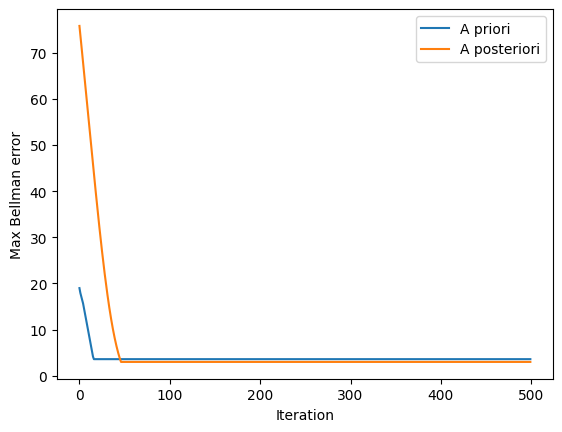

In [40]:
params = QueueingSystemParams(
    arrival_rate=0.30,
    num_servers=2,
    service_rate=0.35,
    class2_arrival_rate=0.20,

    class1_reward=5.0,
    class2_reward=6.0,
    outsourcing_cost=3.0,
    congestion_sensitivity=0.30,

    max_queue_length=15,
    convergence_tolerance=1e-4,
    max_iterations=500
)

V_apriori, conv_apriori = solve(bellman_update_apriori, params)

V_aposteriori, conv_aposteriori = solve(bellman_update_aposteriori, params)

states = build_state_space(params)

plt.plot(conv_apriori, label="A priori")
plt.plot(conv_aposteriori, label="A posteriori")

#plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Max Bellman error")
plt.legend()
plt.show()

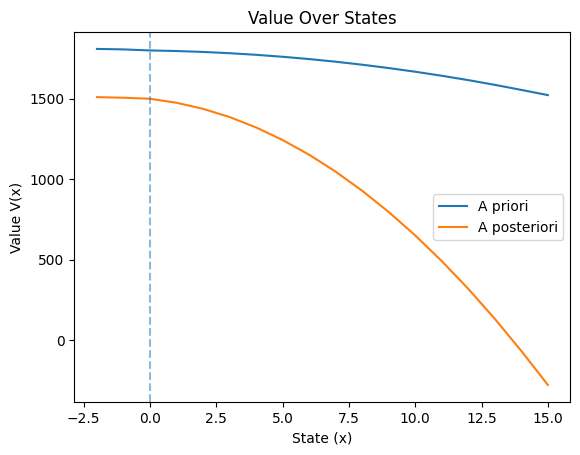

In [41]:
# It is interesting that most of the time, it is better to just do a priori, which means you 
plt.plot(states, V_apriori, label="A priori")
plt.plot(states, V_aposteriori, label="A posteriori")

plt.title("Value Over States")
plt.axvline(0, linestyle="--", alpha=0.5)
plt.xlabel("State (x)")
plt.ylabel("Value V(x)")
plt.legend()
plt.show()

# To deal with optimizing for throughput

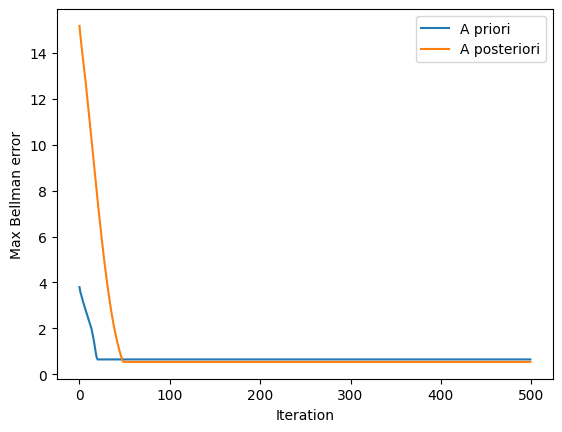

In [42]:
params = QueueingSystemParams(
    arrival_rate=0.30,
    num_servers=2,
    service_rate=0.35,
    class2_arrival_rate=0.20,

    class1_reward=1,
    class2_reward=1,
    outsourcing_cost=3.0,
    congestion_sensitivity=0.30,

    max_queue_length=15,
    convergence_tolerance=1e-4,
    max_iterations=500
)

V_apriori, conv_apriori = solve(bellman_update_apriori, params)

V_aposteriori, conv_aposteriori = solve(bellman_update_aposteriori, params)

states = build_state_space(params)

plt.plot(conv_apriori, label="A priori")
plt.plot(conv_aposteriori, label="A posteriori")

#plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Max Bellman error")
plt.legend()
plt.show()

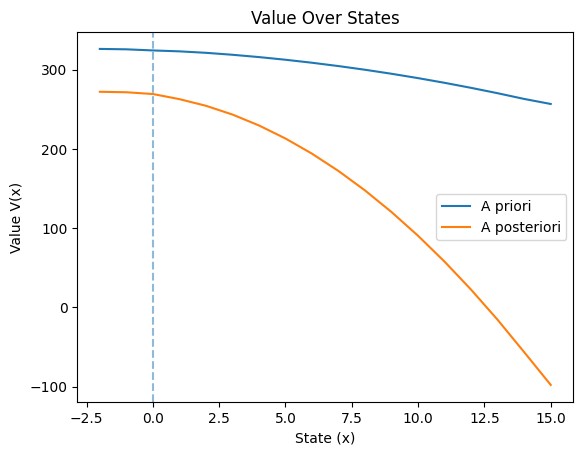

In [43]:
# It is interesting that most of the time, it is better to just do a priori, which means you 
plt.plot(states, V_apriori, label="A priori")
plt.plot(states, V_aposteriori, label="A posteriori")

plt.title("Value Over States")
plt.axvline(0, linestyle="--", alpha=0.5)
plt.xlabel("State (x)")
plt.ylabel("Value V(x)")
plt.legend()
plt.show()

# Dealing with Customer Lifetime Value

The original model used a scalar reward of $r_1$ for every Class 1 arrival, so every customer was worth the same fixed amount. I  replaced with a log-Normal random variable that gives each customer a different realized value, drawn from a distribution parameterized by $(\mu_L, \sigma_L)$.


A customer's lifetime value $R$ is assumed to follow:

$$\ln R \sim \mathcal{N}(\mu_L,\ \sigma_L^2)$$

The expected value (the "mean dice roll") is:

$$E[R] = e^{\mu_L + \frac{\sigma_L^2}{2}}$$


The original Bellman updates contained a manual `congestion_adjustment` term that linearly scaled $r_1$ by a factor involving the queue state and `service_prob`. This was removed because the exponential decay in $R_{\text{realized}}(x)$ already handles congestion sensitivity in a principled way.


In [70]:
@dataclass
class QueueingSystemParams:
    arrival_rate: float                 # lambda
    num_servers: int                    # s
    service_rate: float                 # mu
    class2_arrival_rate: float          # gamma (secondary process)

    # Stochastic CLV Parameters (replaces class1_reward)
    clv_mu: float                       # mu_L: log-mean of CLV distribution
    clv_sigma: float                    # sigma_L: log-std of CLV distribution

    class2_reward: float                # r2
    outsourcing_cost: float             # L
    congestion_sensitivity: float       # omega

    max_queue_length: int               # X_MAX
    convergence_tolerance: float        # EPS
    max_iterations: int                 # MAX_ITER

def expected_clv(params: QueueingSystemParams) -> float:
    """
    Computes E[R] = exp(mu + sigma^2 / 2), the expected value of the
    Log-Normal CLV distribution. This is the 'mean dice roll' — the
    risk-neutral value the agent assigns to a Class 1 arrival before
    observing which customer type (regular vs. whale) has actually arrived.
    """
    return np.exp(params.clv_mu + 0.5 * params.clv_sigma ** 2)


def state_adjusted_clv(state: int, params: QueueingSystemParams) -> float:
    """
    Applies congestion decay to E[R] to get R_realized(x) = E[R] * exp(-omega * max(x, 0))
    """
    base_reward = expected_clv(params)
    congestion_penalty = params.congestion_sensitivity * max(state, 0)
    return base_reward * np.exp(-congestion_penalty)

def class1_decision_value(state: int, value_function: np.ndarray, params: QueueingSystemParams) -> float:
    """
    U_k(x): Decision value for a Class 1 arrival at queue state x.
    """
    index = get_state_index(state, params)
    clv = state_adjusted_clv(state, params)

    if state < 0:
        # Immediate service: reward is collected now, no outsourcing decision.
        return value_function[index] + clv

    # Active decision: queue vs. outsource
    next_queue_value = (
        value_function[index + 1] if index + 1 < len(value_function)
        else value_function[index]
    )
    outsource_value = value_function[index] - params.outsourcing_cost

    return max(next_queue_value, outsource_value)


def class2_decision_value(state: int, value_function: np.ndarray, params: QueueingSystemParams) -> float:
    """
    W_k(x): Decision value for a Class 2 arrival at state x.
    Uses class2_reward (r2), which is unchanged by the CLV integration.
    """
    index = get_state_index(state, params)

    if state < 0:
        idle_value = value_function[index]
        initiate_service_value = (
            value_function[index + 1] if index + 1 < len(value_function)
            else value_function[index]
        ) + params.class2_reward

        return max(idle_value, initiate_service_value)

    return value_function[index]


def bellman_update_apriori(value_function: np.ndarray, params: QueueingSystemParams) -> np.ndarray:
    """
    A priori Bellman update: Class 1 decision is made BEFORE the arrival
    is fully processed (early commitment).
    """
    normalization = params.arrival_rate + params.num_servers * params.service_rate
    arrival_prob = params.arrival_rate / normalization
    service_prob = params.service_rate / normalization

    new_value_function = np.zeros_like(value_function)
    state_space = build_state_space(params)

    for i, state in enumerate(state_space):
        busy_servers = min(params.num_servers, params.num_servers + state)
        effective_service_rate = busy_servers * service_prob

        class1_value = class1_decision_value(state, value_function, params)
        class2_value = class2_decision_value(state, value_function, params)

        previous_service_value = (
            class2_decision_value(state - 1, value_function, params)
            if state - 1 >= -params.num_servers else 0.0
        )

        # NOTE: The old manual congestion_adjustment using class1_reward is
        # removed here. Decay is now embedded in state_adjusted_clv() called
        # within class1_decision_value(), keeping separation of concerns clean.

        new_value_function[i] = (
            arrival_prob * class1_value +
            effective_service_rate * previous_service_value +
            (1 - arrival_prob - effective_service_rate) * class2_value
        )

    return new_value_function

def bellman_update_aposteriori(value_function: np.ndarray, params: QueueingSystemParams) -> np.ndarray:
    """
    A posteriori Bellman update: outsourcing decision is made AFTER the
    system has observed the full arrival (late commitment).
    """
    normalization = (
        params.arrival_rate +
        params.num_servers * params.service_rate +
        params.class2_arrival_rate
    )

    arrival_prob = params.arrival_rate / normalization
    service_prob = params.service_rate / normalization
    class2_prob = params.class2_arrival_rate / normalization

    new_value_function = np.zeros_like(value_function)
    state_space = build_state_space(params)

    for i, state in enumerate(state_space):

        if state <= 0:
            # For x < 0: immediate service, no outsourcing — full CLV, no decay.
            # For x = 0: class1_decision_value handles the queue/outsource split.
            class1_value = (
                value_function[i] + state_adjusted_clv(state, params)
                if state < 0
                else class1_decision_value(state, value_function, params)
            )

            class2_value = class2_decision_value(state, value_function, params)
            effective_service_rate = (params.num_servers + state) * service_prob

            previous_service_value = (
                class2_decision_value(state - 1, value_function, params)
                if state - 1 >= -params.num_servers else 0.0
            )

            new_value_function[i] = (
                arrival_prob * class1_value +
                effective_service_rate * previous_service_value +
                (1 - arrival_prob - effective_service_rate) * class2_value
            )

        else:
            # x > 0: congested queue. CLV decay is active via state_adjusted_clv
            # inside class1_decision_value. FIL operator handles geometric
            # waiting-time aggregation and is CLV-independent.
            class1_value = class1_decision_value(state, value_function, params)
            fil_value = fil_waiting_time_operator(state, value_function, params)
            class2_value = class2_decision_value(state, value_function, params)

            # Removed: old manual congestion_adjustment with division by class2_prob.
            # Congestion sensitivity is now fully handled by state_adjusted_clv().

            new_value_function[i] = (
                class2_prob * class1_value +
                params.num_servers * service_prob * fil_value +
                (1 - class2_prob - params.num_servers * service_prob) * class2_value
            )

    return new_value_function




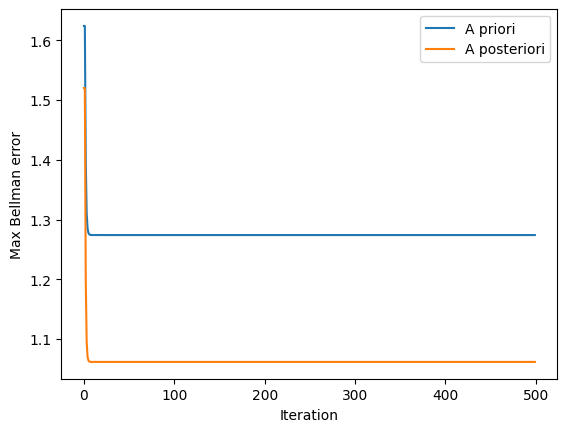

In [ ]:
params = QueueingSystemParams(
    arrival_rate=0.30,
    num_servers=2,
    service_rate=0.35,
    class2_arrival_rate=0.20,

    clv_mu = 1,
    clv_sigma = 0.5,
    class2_reward=1,
    outsourcing_cost=3.0,
    congestion_sensitivity=0.20,

    max_queue_length=20,
    convergence_tolerance=1e-4,
    max_iterations=500
)

V_apriori, conv_apriori = solve(bellman_update_apriori, params)

V_aposteriori, conv_aposteriori = solve(bellman_update_aposteriori, params)

states = build_state_space(params)

plt.plot(conv_apriori, label="A priori")
plt.plot(conv_aposteriori, label="A posteriori")

#plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Max Bellman error")
plt.legend()
plt.show()

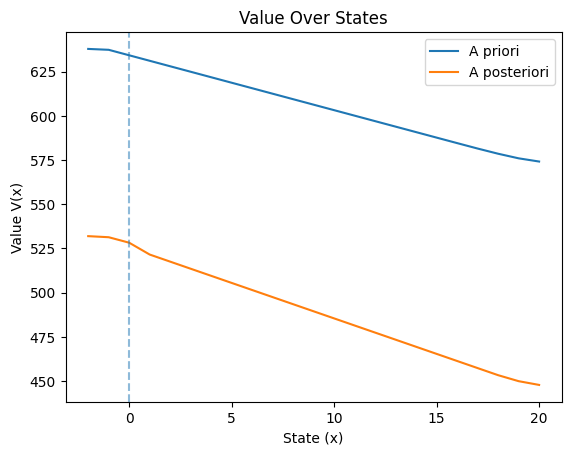

In [72]:
# It is interesting that most of the time, it is better to just do a priori, which means you 
plt.plot(states, V_apriori, label="A priori")
plt.plot(states, V_aposteriori, label="A posteriori")

plt.title("Value Over States")
plt.axvline(0, linestyle="--", alpha=0.5)
plt.xlabel("State (x)")
plt.ylabel("Value V(x)")
plt.legend()
plt.show()

In [73]:
def extract_policy(value_function: np.ndarray, state_space: list, params) -> list[str]:
    policy = []
    for state in state_space:
        if state < 0:
            policy.append("immediate_service")
        else:
            index = get_state_index(state, params)
            next_index = index + 1 if index + 1 < len(value_function) else index
            queue_val = value_function[next_index]
            outsource_val = value_function[index] - params.outsourcing_cost
            policy.append("queue" if queue_val >= outsource_val else "outsource")
    return policy
 
 
def print_policy_table(value_function: np.ndarray, params):
    state_space = build_state_space(params)
    policy = extract_policy(value_function, state_space, params)
 
    er = np.exp(params.clv_mu + 0.5 * params.clv_sigma ** 2)
 
    ACTION_ICON = {
        "immediate_service": ">>",   # blue
        "queue":             " Q",   # green
        "outsource":         " X",   # red
    }
    RESET = "\033[0m"
 
    col_w = 22
    sep = "─" * (7 + col_w + 14 + 12 + 12)
 
    print()
    print(f"  E[R] = exp({params.clv_mu} + {params.clv_sigma}²/2) = {er:.3f}   "
          f"L = {params.outsourcing_cost}   ω = {params.congestion_sensitivity}")
    print()
    print(f"  {'state':>5}  {'action':<{col_w}}  {'R_realized':>10}  {'V(x)':>10}")
    print(f"  {sep}")
 
    prev_zone = None
    for state, action in zip(state_space, policy):
        # zone divider
        zone = "idle" if state < 0 else ("queue" if action == "queue" else "outsource")
        if zone != prev_zone and prev_zone is not None:
            print(f"  {'·'*len(sep)}")
        prev_zone = zone
 
        r_realized = er * np.exp(-params.congestion_sensitivity * max(state, 0))
        index = get_state_index(state, params)
        v = value_function[index]
 
        icon = ACTION_ICON[action]
        action_str = f"{icon}  {action}{RESET}"
 
        print(f"  x={state:>3}   {icon}{RESET}  {action:<18}  "
              f"{r_realized:>8.3f}   {v:>10.4f}")
 
    print(f"  {sep}")
 
    queue_states   = [s for s, a in zip(state_space, policy) if a == "queue"]
    out_states     = [s for s, a in zip(state_space, policy) if a == "outsource"]
    idle_states    = [s for s, a in zip(state_space, policy) if a == "immediate_service"]
    threshold      = min(out_states) if out_states else None
 
    if threshold is not None:
        print(f"\n  Outsource threshold x* = {threshold}  "
              f"(R_realized drops below L={params.outsourcing_cost} here)")
    else:
        print(f"\n  No outsourcing — R_realized > L={params.outsourcing_cost} for all queue states.")
    print()


In [75]:
sigma_range = np.arange(0.1, 2.6, 0.15)
omega_range = np.arange(0.0, 1.05, 0.05)
L_range     = np.arange(1.0, 31.0, 1.0)


In [74]:
n = len(build_state_space(params))
dummy_vf = np.linspace(0, 20, n)

print_policy_table(dummy_vf, params)



  E[R] = exp(1 + 0.5²/2) = 3.080   L = 3.0   ω = 0.3

  state  action                  R_realized        V(x)
  ───────────────────────────────────────────────────────────────────
  x= -2   >>  immediate_service      3.080       0.0000
  x= -1   >>  immediate_service      3.080       0.9091
  ···································································
  x=  0    Q  queue                  3.080       1.8182
  x=  1    Q  queue                  2.282       2.7273
  x=  2    Q  queue                  1.690       3.6364
  x=  3    Q  queue                  1.252       4.5455
  x=  4    Q  queue                  0.928       5.4545
  x=  5    Q  queue                  0.687       6.3636
  x=  6    Q  queue                  0.509       7.2727
  x=  7    Q  queue                  0.377       8.1818
  x=  8    Q  queue                  0.279       9.0909
  x=  9    Q  queue                  0.207      10.0000
  x= 10    Q  queue                  0.153      10.9091
  x= 11    Q  queue  

In [85]:

 
# =============================================================================
# NEW: value iteration + threshold extraction built on top of your code
# =============================================================================
 
def value_iteration(params: QueueingSystemParams, mode: str = "apriori") -> np.ndarray:
    assert mode in ("apriori", "aposteriori")
    update_fn = bellman_update_apriori if mode == "apriori" else bellman_update_aposteriori
    vf = np.zeros(len(build_state_space(params)))
    for _ in range(params.max_iterations):
        new_vf = update_fn(vf, params)
        if np.max(np.abs(new_vf - vf)) < params.convergence_tolerance:
            break
        vf = new_vf
    return vf
 
 
def get_outsource_threshold(params: QueueingSystemParams, mode: str = "apriori"):
    """
    Finds x* = the lowest queue state (x >= 0) where the agent outsources.
    Returns None if the agent never outsources within the queue horizon.
    """
    vf = value_iteration(params, mode)
    for state in build_state_space(params):
        if state < 0:
            continue
        idx = get_state_index(state, params)
        next_idx = idx + 1 if idx + 1 < len(vf) else idx
        if vf[next_idx] < vf[idx] - params.outsourcing_cost:
            return state
    return None
 
 
def threshold_or_max(params: QueueingSystemParams, mode: str):
    t = get_outsource_threshold(params, mode)
    return t if t is not None else params.max_queue_length + 1  # sentinel = never outsources
 
 
# Baseline params
BASE = QueueingSystemParams(
    arrival_rate=3.0,
    num_servers=4,
    service_rate=2.0,
    class2_arrival_rate=1.0,
    clv_mu=2.0,
    clv_sigma=0.8,
    class2_reward=2.0,
    outsourcing_cost=8.0,
    congestion_sensitivity=0.2,
    max_queue_length=15,
    convergence_tolerance=1e-6,
    max_iterations=10_000,
)
 
MODES  = ["apriori", "aposteriori"]
COLORS = {"apriori": "#1D9E75", "aposteriori": "#378ADD"}
LABELS = {"apriori": "a priori", "aposteriori": "a posteriori"}
 
# Ranges to experiment over
sigma_range = np.arange(0.1, 2.6,  0.15)
omega_range = np.arange(0.0, 1.05, 0.05)
L_range     = np.arange(1.0, 31.0, 1.0)
 
# Running sweeps 
print("Running sigma_L sweep...")
sigma_thresholds = {m: [] for m in MODES}
for s in sigma_range:
    p = replace(BASE, clv_sigma=round(float(s), 4))
    for m in MODES:
        sigma_thresholds[m].append(threshold_or_max(p, m))
 
print("Running omega sweep...")
omega_thresholds = {m: [] for m in MODES}
for w in omega_range:
    p = replace(BASE, congestion_sensitivity=round(float(w), 4))
    for m in MODES:
        omega_thresholds[m].append(threshold_or_max(p, m))
 
print("Running L sweep...")
L_thresholds = {m: [] for m in MODES}
for L in L_range:
    p = replace(BASE, outsourcing_cost=round(float(L), 4))
    for m in MODES:
        L_thresholds[m].append(threshold_or_max(p, m))

Running sigma_L sweep...
Running omega sweep...
Running L sweep...


Done. Plotting...


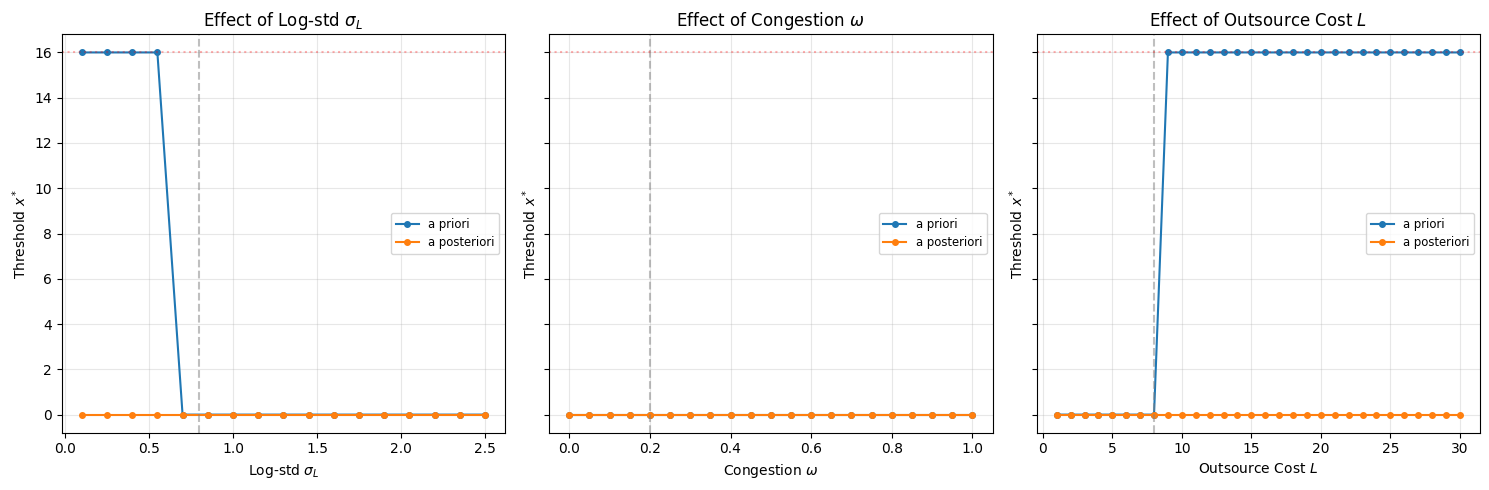

In [87]:
print("Done. Plotting...")
# Plotting time
NEVER = BASE.max_queue_length + 1
 
def plot_sensitivity(ax, x_vals, thresholds, xlabel, baseline, title):
    # Plot each mode line
    for m in MODES:
        ax.plot(x_vals, thresholds[m], label=LABELS[m], marker='o', markersize=4)
    
    # Simple baseline and "Never" markers
    ax.axvline(baseline, color="gray", linestyle="--", alpha=0.5)
    ax.axhline(NEVER, color="red", linestyle=":", alpha=0.3)
    
    # Labeling
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Threshold $x^*$")
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

# Setup the figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Data mapping to iterate instead of repeating function calls
configs = [
    (sigma_range, sigma_thresholds, "Log-std $\sigma_L$", BASE.clv_sigma),
    (omega_range, omega_thresholds, "Congestion $\omega$", BASE.congestion_sensitivity),
    (L_range, L_thresholds, "Outsource Cost $L$", BASE.outsourcing_cost)
]

for i, (x, data, label, base) in enumerate(configs):
    plot_sensitivity(axes[i], x, data, label, base, f"Effect of {label}")

plt.tight_layout()
plt.show()